Imports & Configuration

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

# Project paths — adjust if running outside the repo root
DATA_DIR   = os.path.join('..', 'data', 'raw')
PROC_DIR   = os.path.join('..', 'data', 'processed')
FIG_DIR    = os.path.join('..', 'report', 'figures')

for d in [DATA_DIR, PROC_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

print(" Imports and paths ready.")

 Imports and paths ready.


Load the Bike Sharing Demand Dataset

In [2]:
csv_path = os.path.join(DATA_DIR, 'bike-sharing', 'train.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded Kaggle Bike Sharing data — {df.shape[0]} rows × {df.shape[1]} columns")
else:
    print(" train.csv not found. Generating synthetic bike-sharing data for demonstration…")
    np.random.seed(RANDOM_STATE)
    n = 8640                       # ~1 year of hourly data (360 days × 24 h)
    hours = np.tile(np.arange(24), n // 24 + 1)[:n]
    seasons = np.random.choice([1, 2, 3, 4], n)
    holiday = np.random.choice([0, 1], n, p=[0.97, 0.03])
    workingday = np.random.choice([0, 1], n, p=[0.3, 0.7])
    weather = np.random.choice([1, 2, 3, 4], n, p=[0.6, 0.25, 0.13, 0.02])
    temp = np.clip(np.random.normal(0.5, 0.2, n), 0.02, 1.0)
    atemp = temp + np.random.normal(0, 0.04, n)
    humidity = np.clip(np.random.normal(0.55, 0.2, n), 0, 1)
    windspeed = np.abs(np.random.normal(0.2, 0.15, n))

    # Create realistic demand: higher in commuting hours, good weather
    base = 50 + 30 * np.sin(np.pi * hours / 12)          # hour effect
    base += 40 * (weather == 1).astype(int)               # clear sky boost
    base -= 20 * (weather >= 3).astype(int)               # bad weather drop
    base += 10 * workingday                                # workday boost
    count = np.clip(np.round(base + np.random.normal(0, 15, n)), 0, None)

    df = pd.DataFrame({
        'datetime': pd.date_range('2023-01-01', periods=n, freq='h'),
        'season': seasons, 'holiday': holiday, 'workingday': workingday,
        'weather': weather, 'temp': temp, 'atemp': atemp,
        'humidity': humidity, 'windspeed': windspeed,
        'casual': np.clip(np.round(count * 0.3 + np.random.normal(0, 5, n)), 0, None),
        'registered': np.clip(np.round(count * 0.7 + np.random.normal(0, 10, n)), 0, None),
        'count': count.astype(int)
    })
    print(f" Synthetic data generated — {df.shape[0]} rows × {df.shape[1]} columns")

df.head()

Loaded Kaggle Bike Sharing data — 10886 rows × 12 columns


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


Exploratory Data Analysis

In [3]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:\n")
df.describe()

Shape: (10886, 12)

Column dtypes:
 datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Missing values:
 datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Basic statistics:



,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


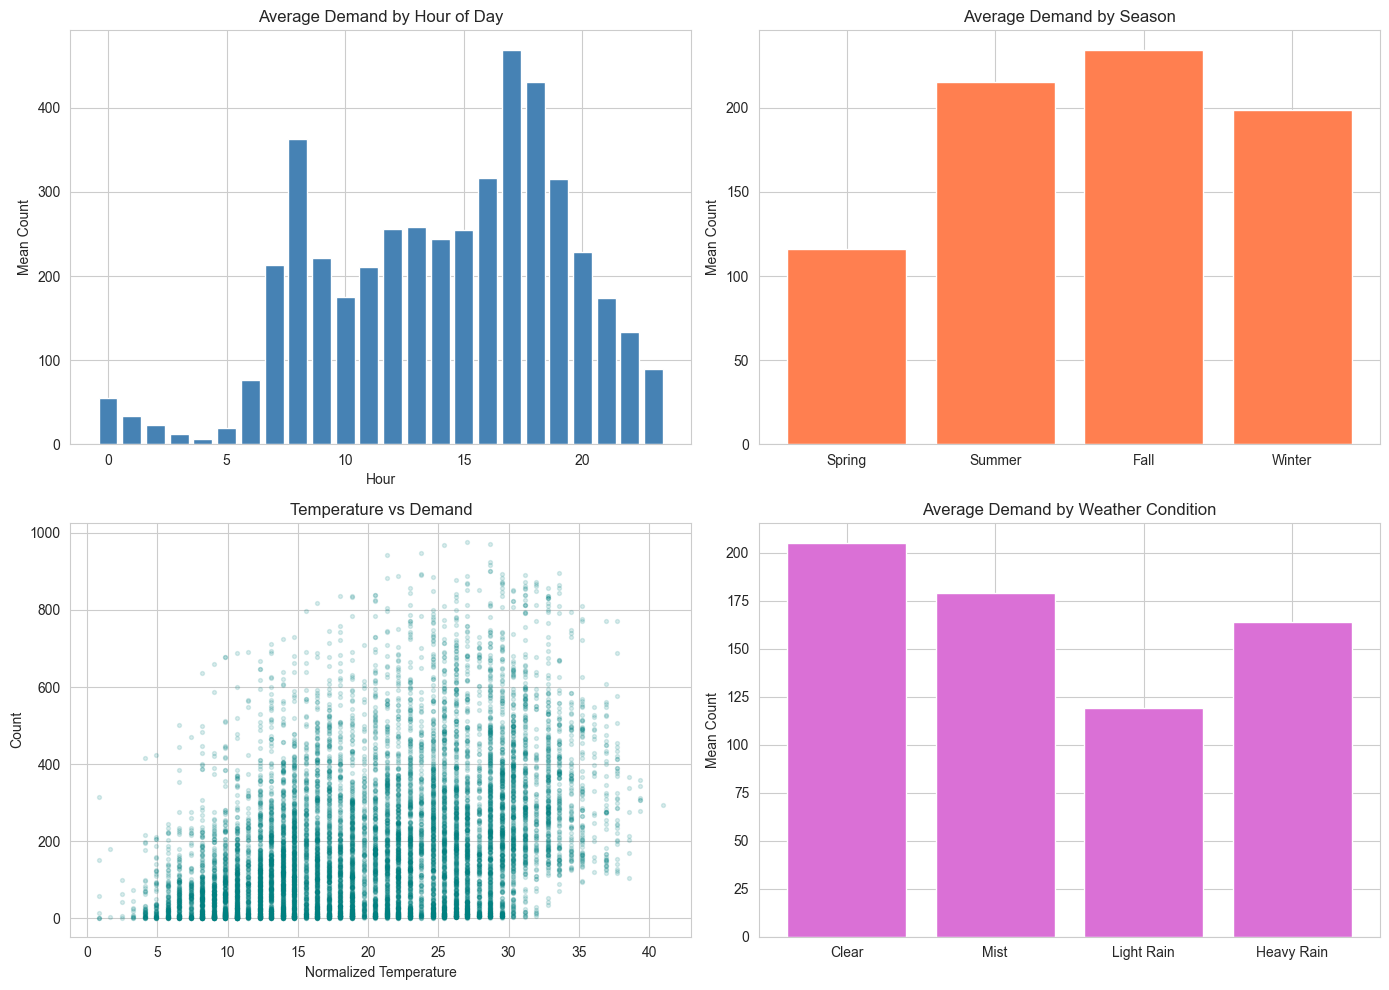

EDA figure saved → report/figures/demand_eda.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly demand pattern
if 'datetime' in df.columns:
    df['hour'] = pd.to_datetime(df['datetime']).dt.hour
else:
    df['hour'] = np.random.randint(0, 24, len(df))

hourly = df.groupby('hour')['count'].mean()
axes[0, 0].bar(hourly.index, hourly.values, color='steelblue')
axes[0, 0].set_title('Average Demand by Hour of Day')
axes[0, 0].set_xlabel('Hour'); axes[0, 0].set_ylabel('Mean Count')

# Season effect
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_name'] = df['season'].map(season_map)
season_avg = df.groupby('season_name')['count'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
axes[0, 1].bar(season_avg.index, season_avg.values, color='coral')
axes[0, 1].set_title('Average Demand by Season')
axes[0, 1].set_ylabel('Mean Count')

# Temperature vs demand
axes[1, 0].scatter(df['temp'], df['count'], alpha=0.15, s=8, color='teal')
axes[1, 0].set_title('Temperature vs Demand')
axes[1, 0].set_xlabel('Normalized Temperature'); axes[1, 0].set_ylabel('Count')

# Weather effect
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain', 4: 'Heavy Rain'}
df['weather_name'] = df['weather'].map(weather_map)
weather_avg = df.groupby('weather_name')['count'].mean().reindex(['Clear', 'Mist', 'Light Rain', 'Heavy Rain'])
axes[1, 1].bar(weather_avg.index, weather_avg.values, color='orchid')
axes[1, 1].set_title('Average Demand by Weather Condition')
axes[1, 1].set_ylabel('Mean Count')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'demand_eda.png'), dpi=150, bbox_inches='tight')
plt.show()
print("EDA figure saved → report/figures/demand_eda.png")

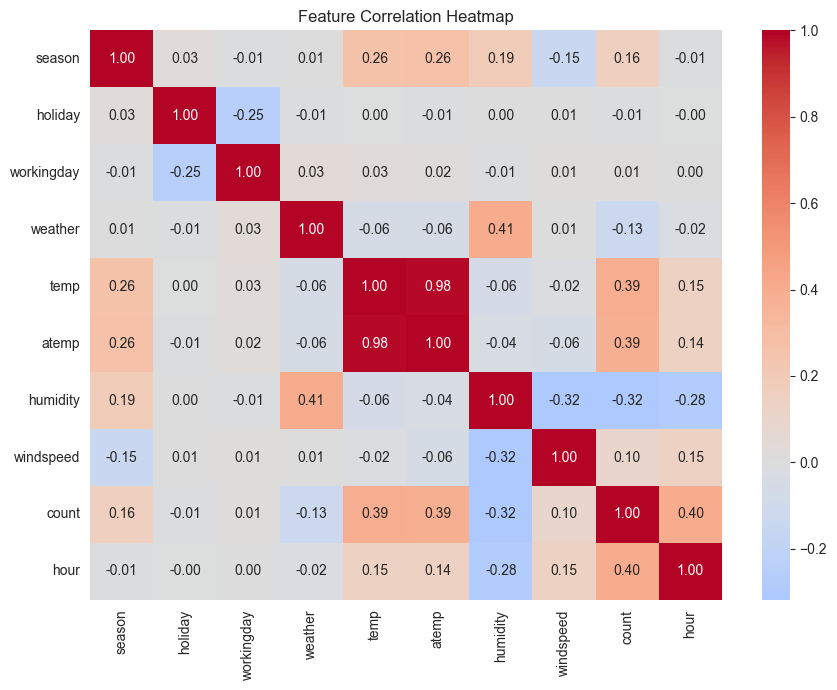

In [5]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['casual', 'registered'], errors='ignore')
corr = df[numeric_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'demand_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

Feature Engineering

In [6]:
# Ensure hour column exists
if 'hour' not in df.columns:
    df['hour'] = pd.to_datetime(df['datetime']).dt.hour

feature_cols = ['hour', 'season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed']
target_col = 'count'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"Feature matrix: {X.shape}")
print(f"Target vector : {y.shape}")
print(f"\nFeatures used: {feature_cols}")
X.head()

Feature matrix: (10886, 8)
Target vector : (10886,)

Features used: ['hour', 'season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed']


,hour,season,holiday,workingday,weather,temp,humidity,windspeed
0,0,1,0,0,1,9.84,81,0.0
1,1,1,0,0,1,9.02,80,0.0
2,2,1,0,0,1,9.02,80,0.0
3,3,1,0,0,1,9.84,75,0.0
4,4,1,0,0,1,9.84,75,0.0


Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Testing set  : {X_test.shape[0]} samples")

Training set : 8708 samples
Testing set  : 2178 samples


Feature Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" StandardScaler fitted on training data.")

 StandardScaler fitted on training data.


Model 1: Linear Regression


In [9]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print(f"  MAE  = {mae_lr:.2f}")
print(f"  RMSE = {rmse_lr:.2f}")
print(f"  R²   = {r2_lr:.4f}")

Linear Regression Results
  MAE  = 107.75
  RMSE = 147.44
  R²   = 0.3414


Random Forest Regressor

In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)           # no scaling needed for trees

y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print(f"  MAE  = {mae_rf:.2f}")
print(f"  RMSE = {rmse_rf:.2f}")
print(f"  R²   = {r2_rf:.4f}")

Random Forest Regressor Results
  MAE  = 47.44
  RMSE = 70.27
  R²   = 0.8504


Model Comparison

            Model    MAE   RMSE   R²
Linear Regression 107.75 147.44 0.34
    Random Forest  47.44  70.27 0.85


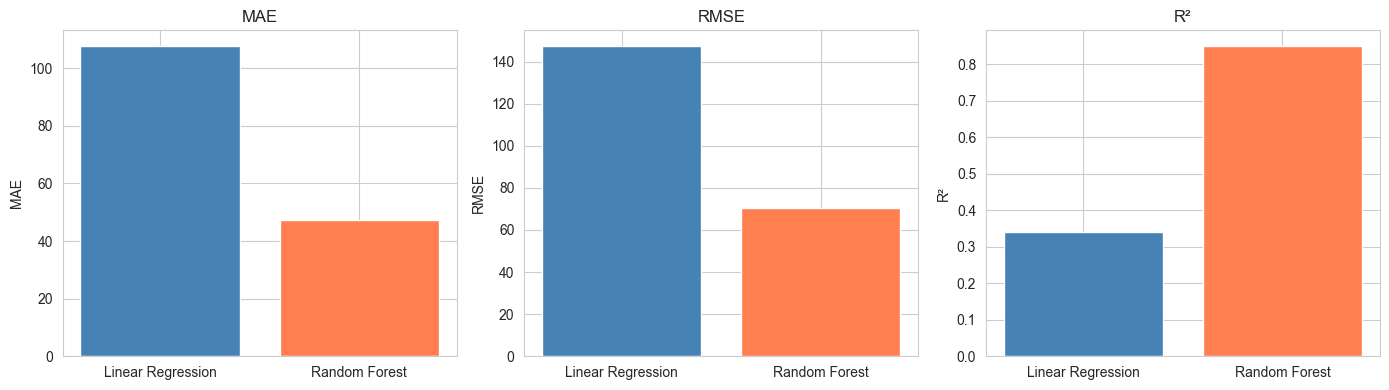

In [15]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':  [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R²':   [r2_lr, r2_rf]
})
comparison = comparison.round(2)
print(comparison.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    axes[i].bar(comparison['Model'], comparison[metric], color=['steelblue', 'coral'])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'demand_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

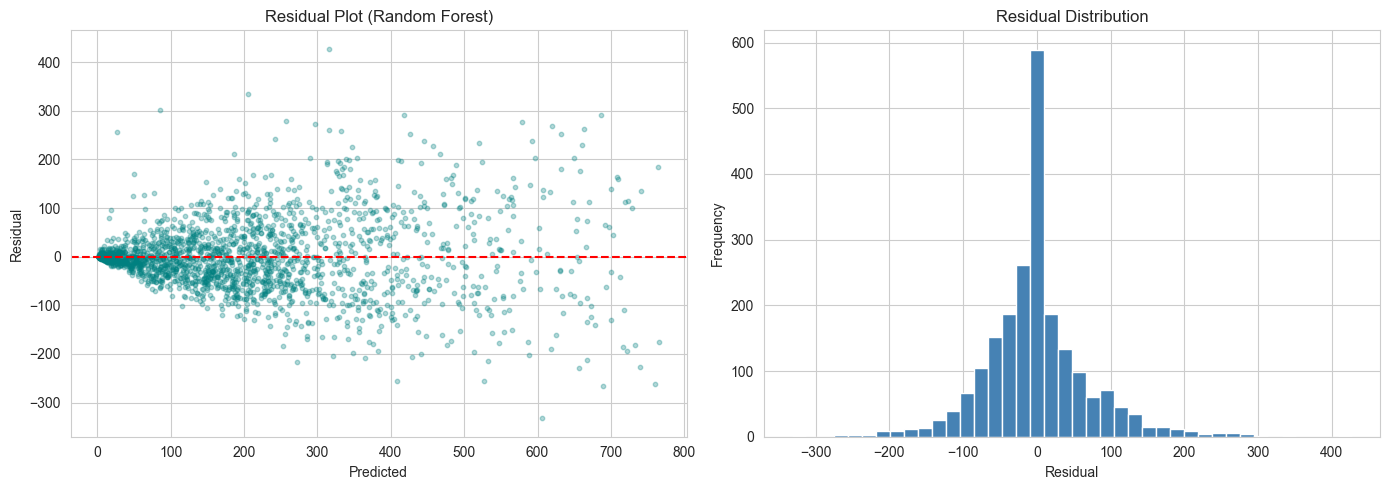

In [16]:
# Residual analysis for the best model (Random Forest)
residuals = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_rf, residuals, alpha=0.3, s=10, color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residual Plot (Random Forest)')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'demand_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()

Feature Importance (Random Forest)

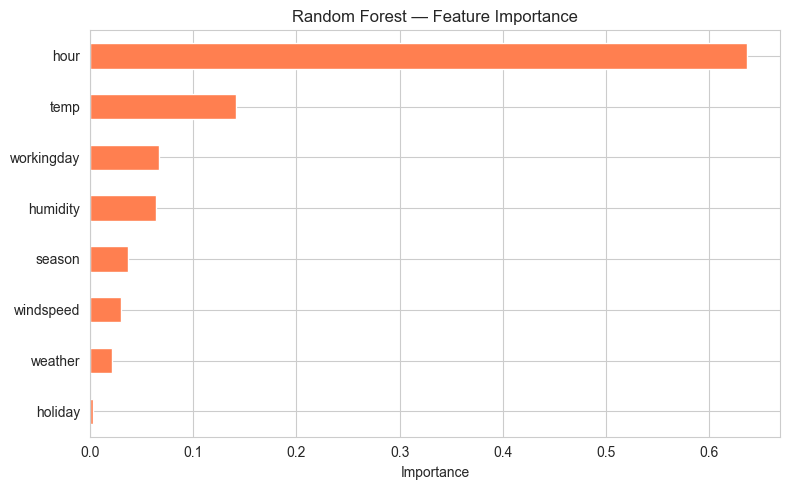

Top features:
 hour          0.636907
temp          0.141022
workingday    0.066677
humidity      0.063491
season        0.037166
dtype: float64


In [17]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot.barh(color='coral')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'demand_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Top features:\n", importances.sort_values(ascending=False).head(5))

Cross-Validation (Robustness Check)

In [18]:
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print("5-Fold CV MAE (lower is better):")
print(f"  Linear Regression : {-cv_scores_lr.mean():.2f} ± {cv_scores_lr.std():.2f}")
print(f"  Random Forest     : {-cv_scores_rf.mean():.2f} ± {cv_scores_rf.std():.2f}")

5-Fold CV MAE (lower is better):
  Linear Regression : 109.12 ± 1.93
  Random Forest     : 47.17 ± 0.50


Integration: Predicting Demand for the Simulation Grid

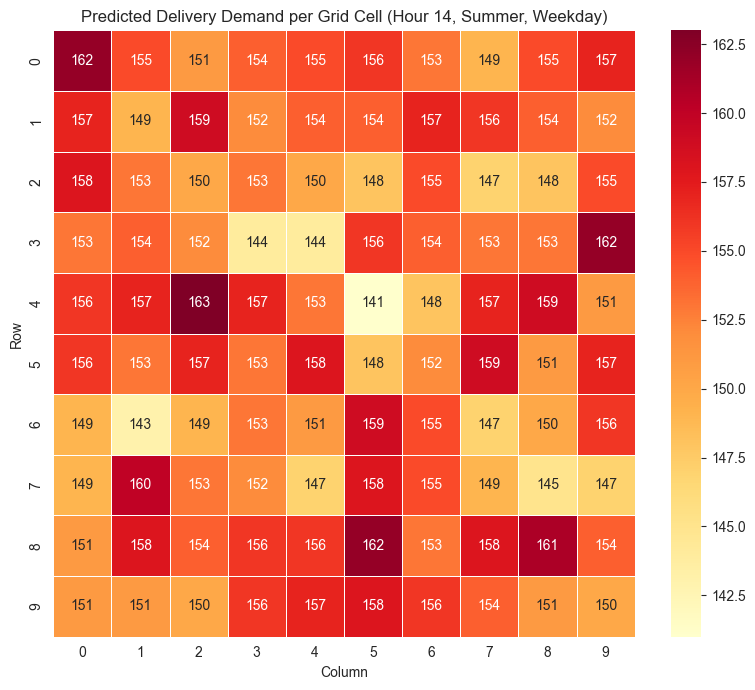

Demand heatmap saved → report/figures/demand_heatmap.png


In [19]:
def predict_grid_demand(hour=14, season=2, holiday=0, workingday=1,
                        weather=1, base_temp=0.6, base_humidity=0.5,
                        base_wind=0.2, grid_size=10, noise_std=15):
    """
    Predict demand for every cell in the 10×10 grid.
    Temperature, humidity, and windspeed vary slightly by zone to
    simulate micro-climate differences.
    Returns a 10×10 numpy array of predicted demand.
    """
    grid_demand = np.zeros((grid_size, grid_size))
    for r in range(grid_size):
        for c in range(grid_size):
            # Add small spatial variation
            temp_var = base_temp + np.random.normal(0, 0.03)
            hum_var  = base_humidity + np.random.normal(0, 0.03)
            wind_var = base_wind + np.random.normal(0, 0.02)

            x_input = pd.DataFrame([{
                'hour': hour, 'season': season, 'holiday': holiday,
                'workingday': workingday, 'weather': weather,
                'temp': np.clip(temp_var, 0, 1),
                'humidity': np.clip(hum_var, 0, 1),
                'windspeed': abs(wind_var)
            }])
            pred = rf.predict(x_input)[0] + np.random.normal(0, noise_std * 0.3)
            grid_demand[r][c] = max(0, round(pred))

    return grid_demand

# Example: predict demand for a typical weekday afternoon
grid_demand = predict_grid_demand(hour=14, season=2, workingday=1)

plt.figure(figsize=(8, 7))
sns.heatmap(grid_demand, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Predicted Delivery Demand per Grid Cell (Hour 14, Summer, Weekday)')
plt.xlabel('Column'); plt.ylabel('Row')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'demand_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Demand heatmap saved → report/figures/demand_heatmap.png")

Save the Final Model & Scaler


In [20]:
model_path  = os.path.join(PROC_DIR, 'demand_model.pkl')
scaler_path = os.path.join(PROC_DIR, 'demand_scaler.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(rf, f)

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f" Model saved  → {model_path}")
print(f"Scaler saved → {scaler_path}")

 Model saved  → ..\data\processed\demand_model.pkl
Scaler saved → ..\data\processed\demand_scaler.pkl


| Item | Value |
|---|---|
| Best model | Random Forest Regressor |
| MAE | See cell 9 output |
| RMSE | See cell 9 output |
| R² | See cell 9 output |
| Top feature | hour (by importance) |
| Saved artifact | `data/processed/demand_model.pkl` |
| Integration | `predict_grid_demand()` maps predictions to the 10×10 grid |

